# FL Sweep — Results Analysis

**Sections**
1. Setup & load
2. Build DataFrames (summary + long-format curves)
3. Distribution × clients
4. Gradient-divergence plateaus
5. FedProx effect per optimizer
6. FedAvg vs FedAdam
7. Learning curves (global val)
8. Dirichlet α heterogeneity
9. FL vs centralized baseline
10. Heatmap + best configs table

## 1. Setup

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#sns.set_theme(style="whitegrid", palette="tab10", font_scale=1)
sns.set_theme(context='paper')
plt.rcParams["figure.dpi"] = 120

RESULTS_DIR = Path("results")   # ← change if you used --results-dir
FIGS_DIR    = Path("figs_analysis")
FIGS_DIR.mkdir(exist_ok=True)

## 2. Load results & build DataFrames

Three tidy DataFrames:
- **`df`** — one row per experiment, scalar metrics (good for bar/scatter plots)
- **`df_curves`** — long format: one row per (experiment, round) for val-loss curves
- **`df_div`** — same for gradient divergence

In [2]:
def load_all(results_dir: Path):
    records = []
    for d in sorted(results_dir.iterdir()):
        p = d / "history.json"
        if d.is_dir() and p.exists():
            data = json.loads(p.read_text())
            data["exp_id"] = d.name
            records.append(data)
    print(f"Loaded {len(records)} / 120 experiments")
    return records

records = load_all(RESULTS_DIR)
by_id   = {r["exp_id"]: r for r in records}

Loaded 120 / 120 experiments


In [3]:
def _dist_label(cfg):
    d = cfg.get("data_distribution", "?")
    return f"dirichlet α={cfg['dirichlet_alpha']}" if d == "dirichlet" else d

def _div_group(opt, reg):
    """Map optimizer × regularization → one of the 3 observed plateau groups."""
    s = "adam(w)" if opt in ("adamw", "adam") else "sgd"
    return s +f', {reg}'
    # if opt in ("adamw", "adam") and reg == "none":    return "adam(w), no FedProx"
    # if opt == "sgd":                                   return f"sgd, {reg}"
    # return "adam(w), FedProx"   # adam(w) + fedprox

# ── summary DataFrame ──────────────────────────────────────────────────────
rows = []
for r in records:
    cfg, h, bh = r["config"], r["history"], r.get("baseline_history") or {}
    gvl = h.get("global_val_loss", [])
    gd  = h.get("grad_divergence", [])
    ltr = [np.mean(x) for x in h.get("local_train_losses", [])]
    lvl = [np.mean(x) for x in h.get("local_val_losses",  [])]
    reg = cfg.get("client_regularization") or "none"
    opt = cfg.get("optimizer")
    rows.append({
        "exp_id":         r["exp_id"],
        "num_clients":    cfg["num_clients"],
        "distribution":   cfg["data_distribution"],
        "dist_label":     _dist_label(cfg),
        "dirichlet_alpha":cfg["dirichlet_alpha"],
        "aggregator":     cfg["aggregator"],
        "regularization": reg,
        "optimizer":      opt,
        "div_group":      _div_group(opt, reg),
        # scalar metrics
        "final_global_val":  gvl[-1]  if gvl else np.nan,
        "best_global_val":   min(gvl) if gvl else np.nan,
        "final_local_train": ltr[-1]  if ltr else np.nan,
        "final_local_val":   lvl[-1]  if lvl else np.nan,
        "mean_grad_div":     np.mean(gd) if gd else np.nan,
        "final_grad_div":    gd[-1]  if gd else np.nan,
        "baseline_final_val": (bh.get("val_loss") or [np.nan])[-1],
        "fl_vs_baseline":    gvl[-1] - (bh.get("val_loss") or [np.nan])[-1] if gvl else np.nan,
        "total_min":         r.get("total_fl_time", np.nan) / 60,
    })

df = pd.DataFrame(rows)
df["clients"] = df["num_clients"].astype(str) + " clients"
print(df.shape)
df.sort_values("final_global_val").head(5)

(120, 19)


,exp_id,num_clients,distribution,dist_label,dirichlet_alpha,aggregator,regularization,optimizer,div_group,final_global_val,best_global_val,final_local_train,final_local_val,mean_grad_div,final_grad_div,baseline_final_val,fl_vs_baseline,total_min,clients
94,c4_dirichlet2.0_fedavg_none_adamw,4,dirichlet,dirichlet α=2.0,2.0,fedavg,none,adamw,"adam(w), none",4.441119,4.441119,4.484256,4.496568,0.231228,0.355864,4.180112,0.261007,6.839885,4 clients
93,c4_dirichlet2.0_fedavg_none_adam,4,dirichlet,dirichlet α=2.0,2.0,fedavg,none,adam,"adam(w), none",4.446316,4.446316,4.487706,4.502630,0.246134,0.380235,4.188895,0.257421,7.100182,4 clients
106,c4_multi_language_fedavg_none_adamw,4,multi_language,multi_language,0.5,fedavg,none,adamw,"adam(w), none",4.446611,4.446611,4.496584,4.263703,0.221623,0.346539,4.181414,0.265196,6.955858,4 clients
105,c4_multi_language_fedavg_none_adam,4,multi_language,multi_language,0.5,fedavg,none,adam,"adam(w), none",4.446938,4.446938,4.495229,4.261152,0.238951,0.374693,4.189163,0.257775,6.588815,4 clients
82,c4_dirichlet0.5_fedavg_none_adamw,4,dirichlet,dirichlet α=0.5,0.5,fedavg,none,adamw,"adam(w), none",4.460881,4.460881,4.509622,4.550578,0.275133,0.370000,4.183453,0.277429,6.776933,4 clients


In [4]:
# ── long-format curves ────────────────────────────────────────────────────
META = ["num_clients","clients","distribution","dist_label","aggregator",
        "regularization","optimizer","div_group"]

curve_rows, div_rows = [], []
for r in records:
    h      = r["history"]
    exp_id = r["exp_id"]
    meta   = df.loc[df["exp_id"]==exp_id, META].iloc[0].to_dict()

    gvl = h.get("global_val_loss", [])
    er  = h.get("eval_rounds", list(range(1, len(gvl)+1)))
    for rnd, val in zip(er, gvl):
        curve_rows.append({"exp_id": exp_id, "round": rnd, "global_val_loss": val, **meta})

    for i, val in enumerate(h.get("grad_divergence", [])):
        div_rows.append({"exp_id": exp_id, "round": i+1, "grad_divergence": val, **meta})

df_curves = pd.DataFrame(curve_rows)
df_div    = pd.DataFrame(div_rows)
print(f"df_curves: {df_curves.shape}  |  df_div: {df_div.shape}")

df_curves: (2400, 11)  |  df_div: (2400, 11)


## 3. Effect of data distribution and number of clients

Mean ± 95 % CI of final global val loss across all (aggregator, regularization, optimizer) combos.

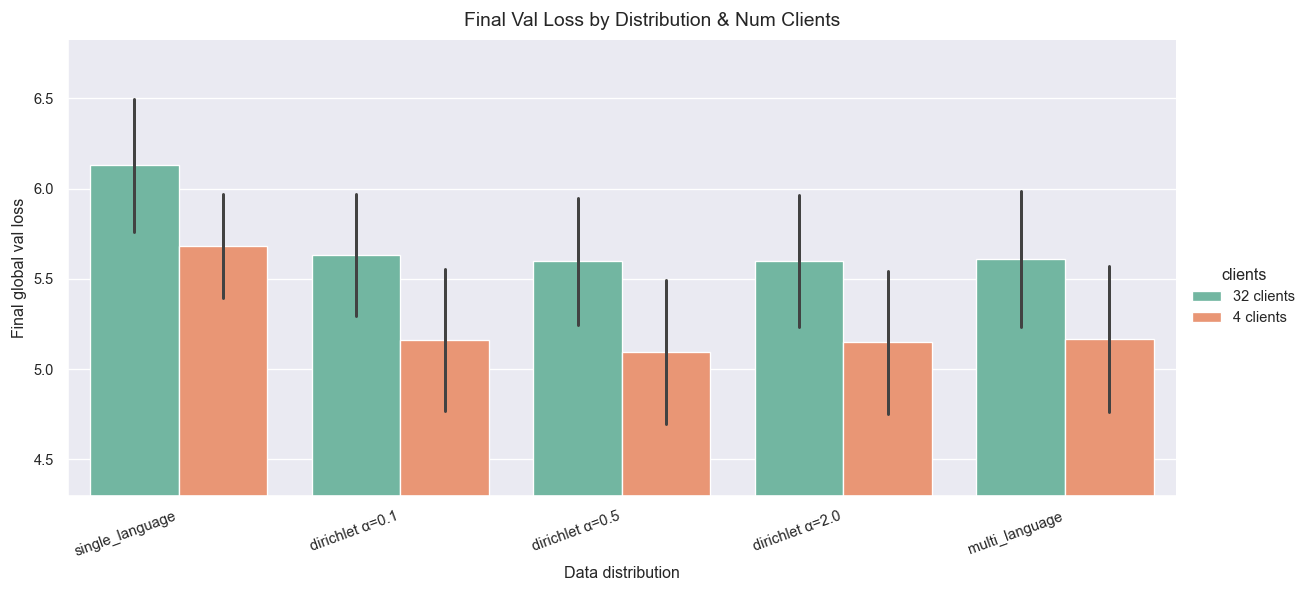

In [5]:
DIST_ORDER = ["single_language","dirichlet α=0.1","dirichlet α=0.5","dirichlet α=2.0", "multi_language",]

g = sns.catplot(data=df, x="dist_label", y="final_global_val", hue="clients",
                order=DIST_ORDER, kind="bar", errorbar="sd",
                height=4.5, aspect=2.2, palette="Set2")
g.set_xticklabels(rotation=20, ha="right")
g.set_axis_labels("Data distribution", "Final global val loss")
g.set_titles(""); g.figure.suptitle("Final Val Loss by Distribution & Num Clients", y=1.02)
g.ax.set_ylim(bottom=4.3)
g.savefig(FIGS_DIR / "01_dist_clients.png", bbox_inches="tight")

In [6]:
# Pivot table for quick reading
df.pivot_table("final_global_val", index="dist_label", columns="num_clients",
               aggfunc=["mean","std"]).round(4)

mean             std        
num_clients          4       32      4       32
dist_label                                     
dirichlet α=0.1  5.1615  5.6317  0.3912  0.3390
dirichlet α=0.5  5.0957  5.5967  0.3967  0.3505
dirichlet α=2.0  5.1484  5.6014  0.3962  0.3656
multi_language   5.1670  5.6105  0.4048  0.3771
single_language  5.6809  6.1295  0.2868  0.3679

## 4. Gradient-divergence plateaus

Three plateau groups you noticed in W&B, shown as average trajectories:
- **adam(w), no FedProx** — lowest
- **sgd, ±FedProx** — middle
- **adam(w), FedProx** — highest

In [7]:
df_div

,exp_id,round,grad_divergence,num_clients,clients,distribution,dist_label,aggregator,regularization,optimizer,div_group
0,c32_dirichlet0.1_fedadam_fedprox_adam,1,0.306213,32,32 clients,dirichlet,dirichlet α=0.1,fedadam,fedprox,adam,"adam(w), fedprox"
1,c32_dirichlet0.1_fedadam_fedprox_adam,2,0.336758,32,32 clients,dirichlet,dirichlet α=0.1,fedadam,fedprox,adam,"adam(w), fedprox"
2,c32_dirichlet0.1_fedadam_fedprox_adam,3,0.431781,32,32 clients,dirichlet,dirichlet α=0.1,fedadam,fedprox,adam,"adam(w), fedprox"
3,c32_dirichlet0.1_fedadam_fedprox_adam,4,0.478146,32,32 clients,dirichlet,dirichlet α=0.1,fedadam,fedprox,adam,"adam(w), fedprox"
4,c32_dirichlet0.1_fedadam_fedprox_adam,5,0.495893,32,32 clients,dirichlet,dirichlet α=0.1,fedadam,fedprox,adam,"adam(w), fedprox"
...,...,...,...,...,...,...,...,...,...,...,...
2395,c4_single_language_fedavg_none_sgd,16,0.502931,4,4 clients,single_language,single_language,fedavg,none,sgd,"sgd, none"
2396,c4_single_language_fedavg_none_sgd,17,0.507286,4,4 clients,single_language,single_language,fedavg,none,sgd,"sgd, none"
2397,c4_single_language_fedavg_none_sgd,18,0.515320,4,4 clients,single_language,single_language,fedavg,none,sgd,"sgd, none"
2398,c4_single_language_fedavg_none_sgd,19,0.522166,4,4 clients,single_language,single_language,fedavg,none,sgd,"sgd, none"


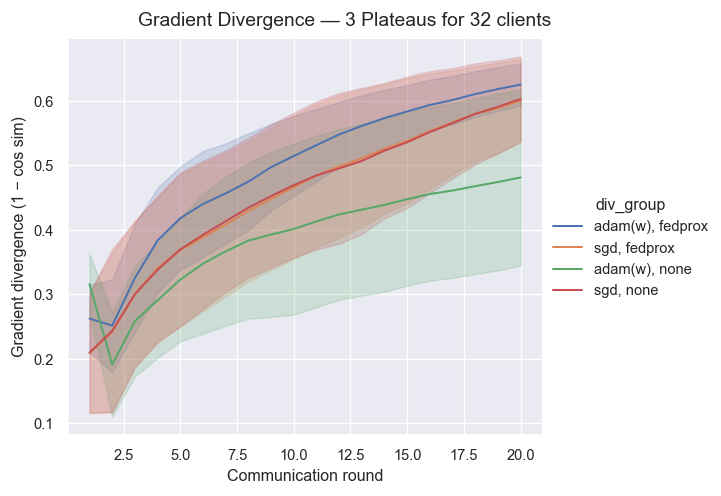

In [8]:
df_div_32 = df_div[df_div["num_clients"] == 32]
g = sns.relplot(data=df_div_32, x="round", y="grad_divergence",
                hue="div_group",
                kind="line", errorbar="sd", height=4, aspect=1.2)
g.set_axis_labels("Communication round", "Gradient divergence (1 − cos sim)")
g.set_titles("{col_name}"); g.figure.suptitle("Gradient Divergence — 3 Plateaus for 32 clients", y=1.02)
#g.figure.subplots_adjust(right=0.73) 
g.savefig(FIGS_DIR / "02_grad_div_plateaus.png", bbox_inches="tight")

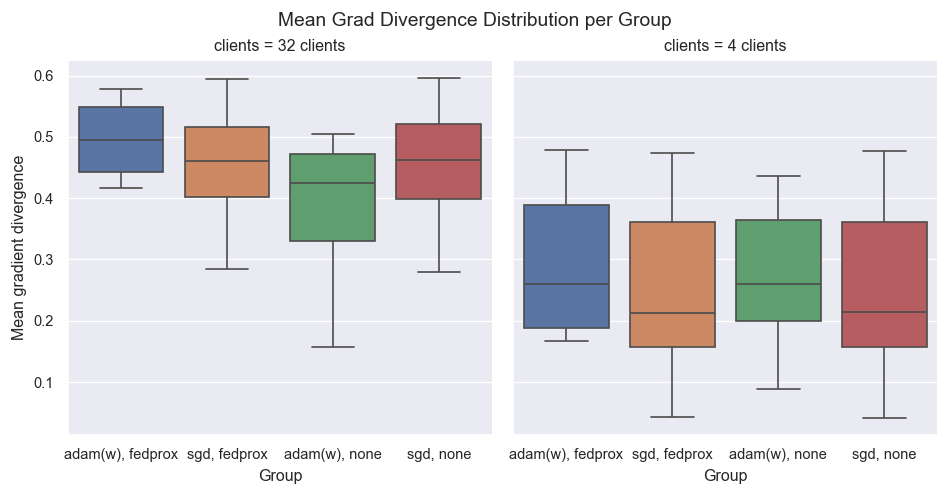

In [9]:
# Box plot of mean divergence per group — easier to see plateau levels
g = sns.catplot(data=df, x="div_group", y="mean_grad_div", col="clients",
                kind="box", height=4, aspect=1, hue="div_group")
g.set_axis_labels("Group", "Mean gradient divergence")
g.figure.suptitle("Mean Grad Divergence Distribution per Group", y=1.02)
g.savefig(FIGS_DIR / "02b_grad_div_box.png", bbox_inches="tight")

In [10]:
df.columns

Index(['exp_id', 'num_clients', 'distribution', 'dist_label',
       'dirichlet_alpha', 'aggregator', 'regularization', 'optimizer',
       'div_group', 'final_global_val', 'best_global_val', 'final_local_train',
       'final_local_val', 'mean_grad_div', 'final_grad_div',
       'baseline_final_val', 'fl_vs_baseline', 'total_min', 'clients'],
      dtype='str')

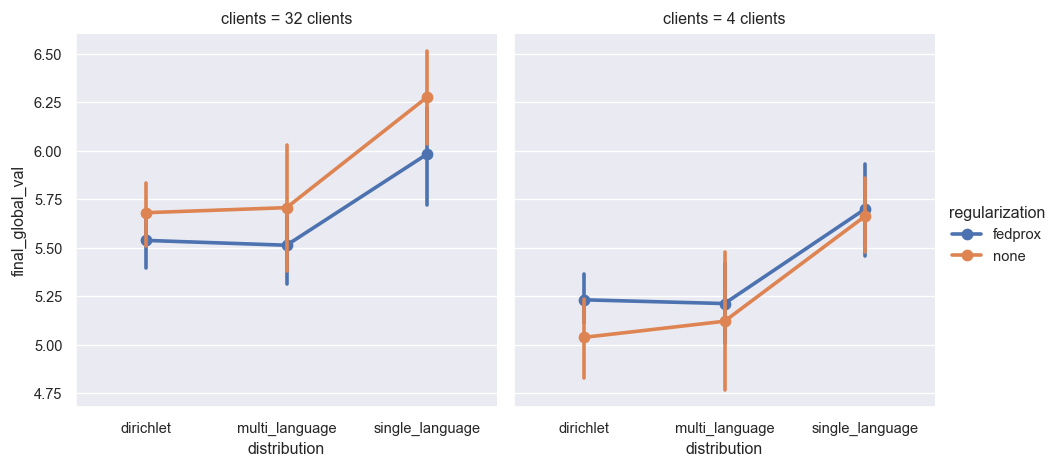

In [11]:
sns.catplot(data=df, x="distribution", y="final_global_val", col="clients",
                kind="point", height=4, aspect=1, hue="regularization")

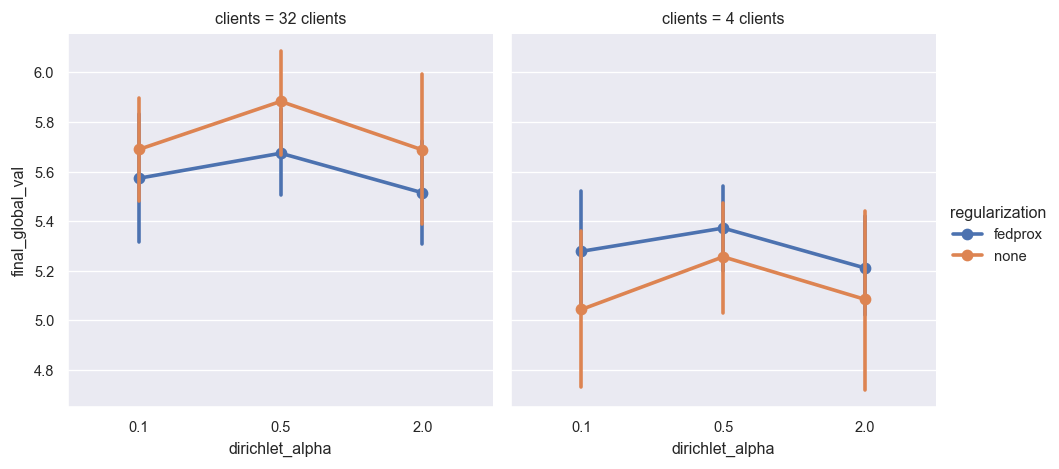

In [12]:
sns.catplot(data=df, x="dirichlet_alpha", y="final_global_val", col="clients",
                kind="point", height=4, aspect=1, hue="regularization")

Text(0.5, 1.02, 'Impact of regularization on final val loss by optimizer and aggregator ')

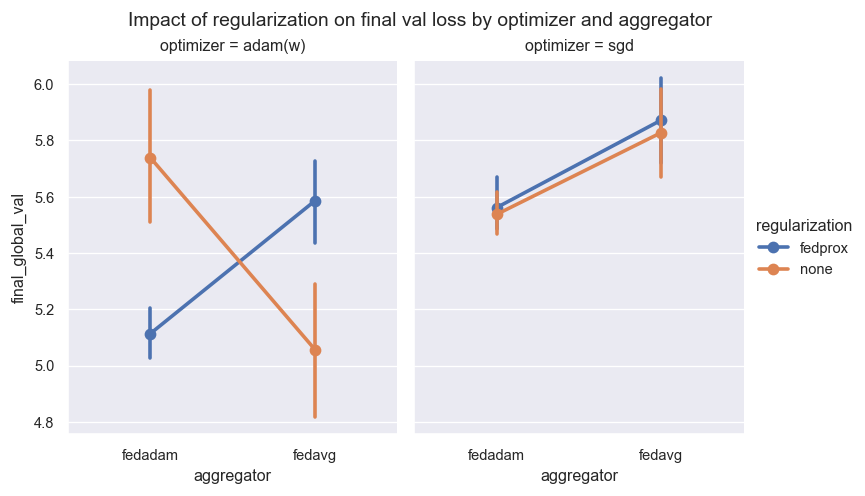

In [13]:
df_opt = df.copy()
df_opt['optimizer'] = df_opt["optimizer"].map(lambda x: "sgd" if x=="sgd" else "adam(w)")
g=sns.catplot(data=df_opt, x="aggregator", y="final_global_val", col="optimizer",
                kind="point", height=4, aspect=.8, hue="regularization")
g.figure.suptitle("Impact of regularization on final val loss by optimizer and aggregator ",y=1.02)

Text(0.5, 1.02, 'Impact of regularization on final grad div by optimizer and aggregator ')

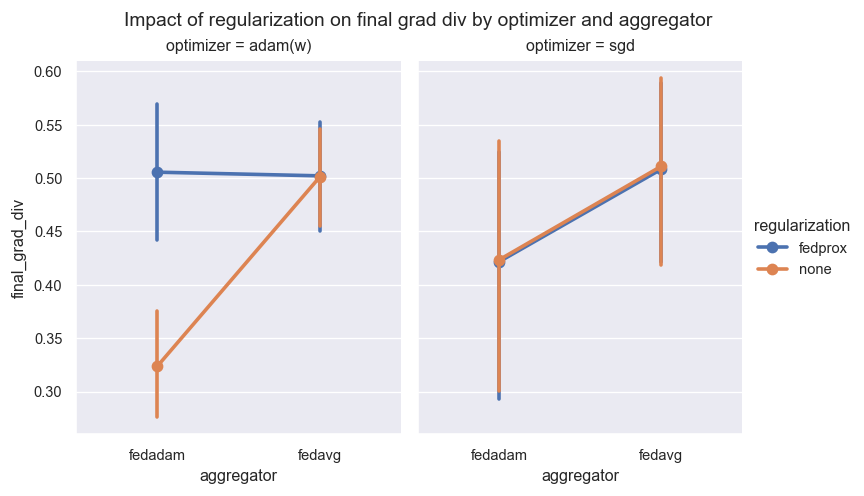

In [14]:
df_opt = df.copy()
df_opt['optimizer'] = df_opt["optimizer"].map(lambda x: "sgd" if x=="sgd" else "adam(w)")
g=sns.catplot(data=df_opt, x="aggregator", y="final_grad_div", col="optimizer",
                kind="point", height=4, aspect=.8, hue="regularization")
g.figure.suptitle("Impact of regularization on final grad div by optimizer and aggregator ",y=1.02)

(<seaborn.axisgrid.FacetGrid at 0x133cf9eb0>,)

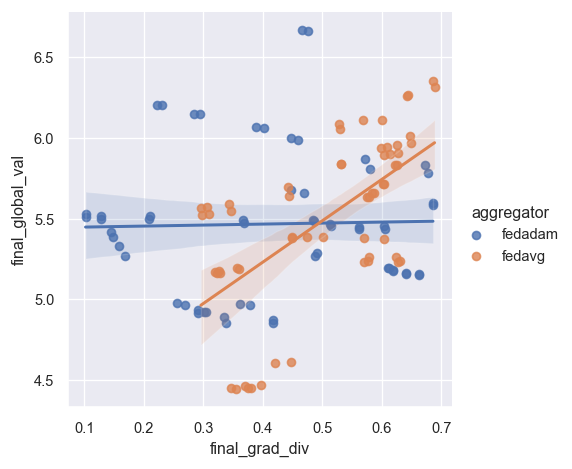

In [15]:
sns.lmplot(data=df_opt, x="final_grad_div", y="final_global_val",
                height=4, aspect=1, hue="aggregator"), #col="regularization", row="distribution")

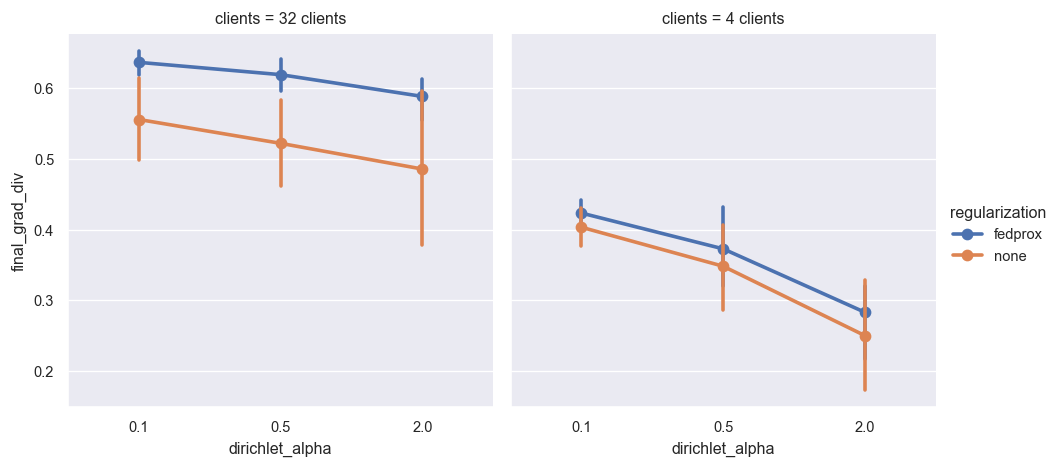

In [16]:
sns.catplot(data=df, x="dirichlet_alpha", y="final_grad_div", col="clients",
                kind="point", height=4, aspect=1, hue="regularization")

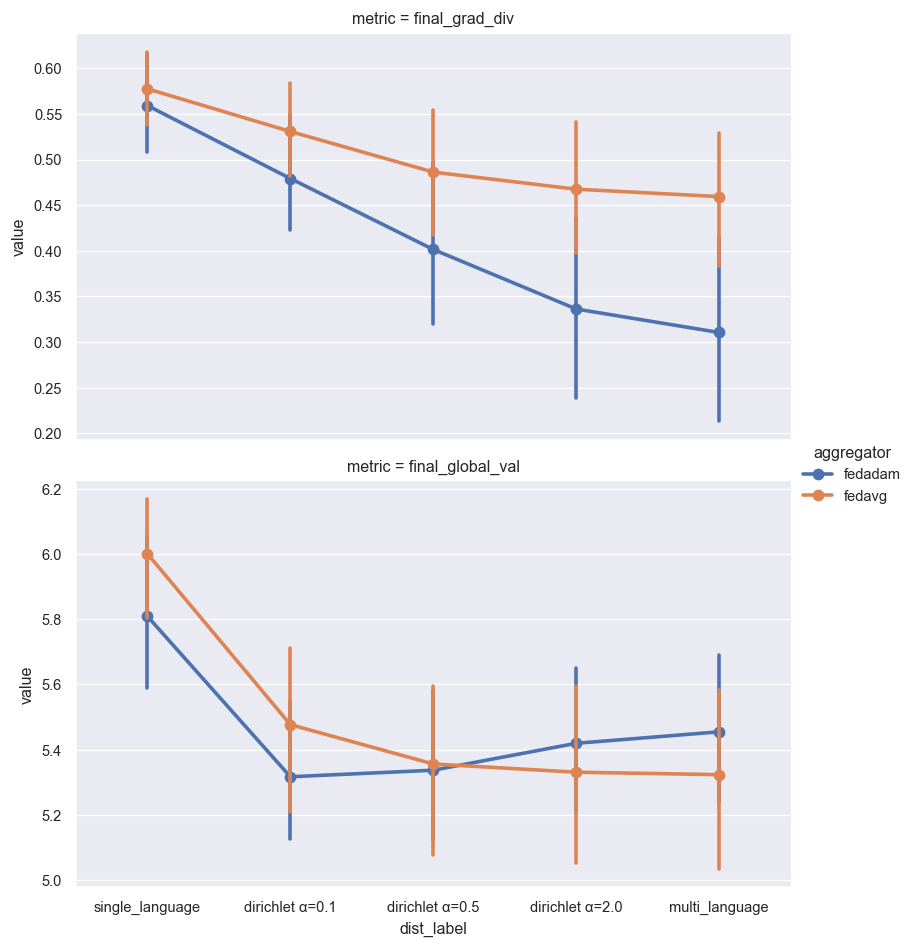

In [17]:
# melt final_grad_div and final_global_val columns into metric column
df_melt = df.melt(id_vars=list(set(df.columns)-{"final_grad_div","final_global_val"}), value_vars=["final_grad_div","final_global_val"], var_name="metric", value_name="value")

sns.catplot(data=df_melt, x="dist_label", y="value", order=DIST_ORDER, row='metric', #row='optimizer',  col='clients',
                kind="point", height=4, aspect=1.7, hue="aggregator", sharey=False)

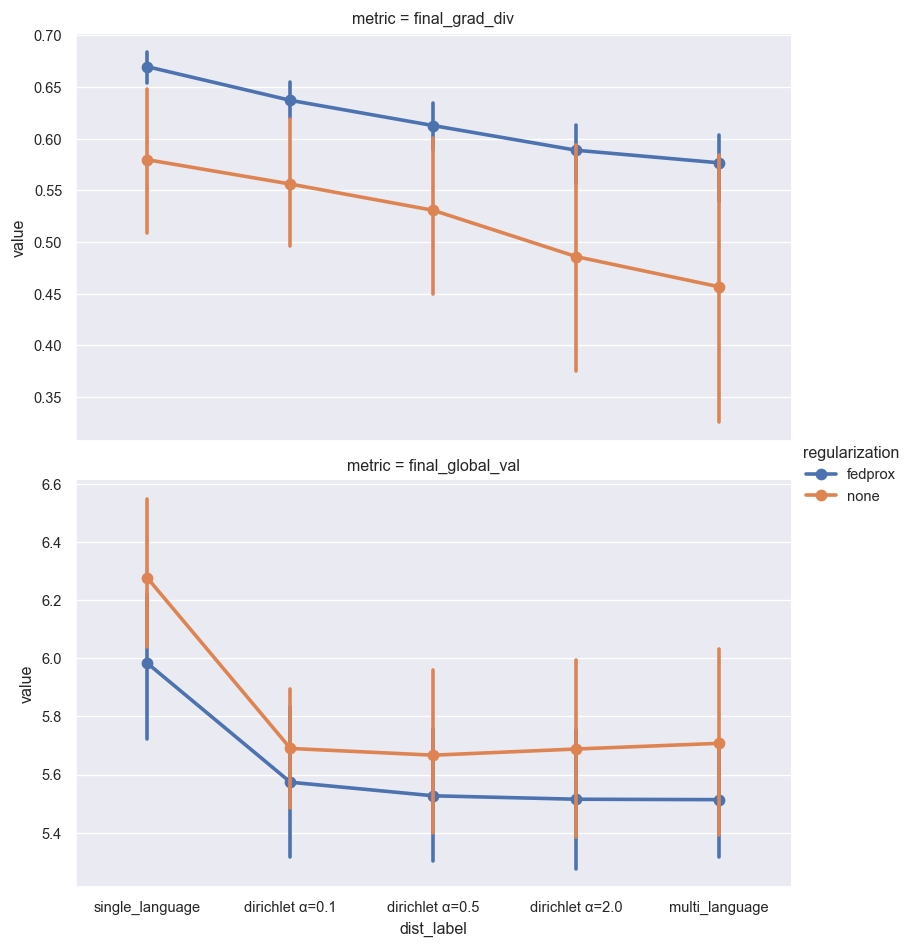

In [18]:
sns.catplot(data=df_melt[df_melt["num_clients"]==32], x="dist_label", y="value", order=DIST_ORDER, row='metric', #row='optimizer',  col='clients',
                kind="point", height=4, aspect=1.7, hue="regularization", sharey=False)

## 5. Effect of FedProx regularization per optimizer

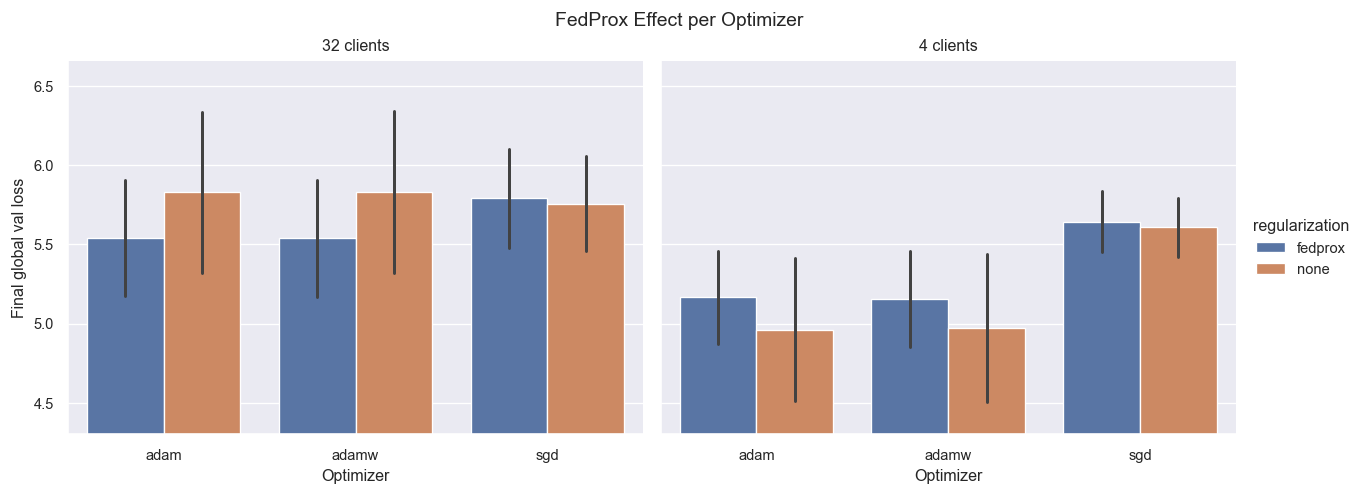

In [19]:
g = sns.catplot(data=df, x="optimizer", y="final_global_val", hue="regularization",
                col="clients", kind="bar", errorbar="sd",
                height=4, aspect=1.3, palette=["#4C72B0","#DD8452"])
g.set_axis_labels("Optimizer", "Final global val loss")
g.set_titles("{col_name}"); g.figure.suptitle("FedProx Effect per Optimizer", y=1.02)
for ax in g.axes.flat: ax.set_ylim(bottom=4.3)
g.savefig(FIGS_DIR / "03_fedprox_effect.png", bbox_inches="tight")

In [20]:
# Delta table: fedprox − none (negative = FedProx helps)
pivot = (df.groupby(["num_clients","optimizer","regularization"])["final_global_val"]
           .mean().unstack("regularization"))
pivot["Δ fedprox−none"] = pivot["fedprox"] - pivot["none"]
pivot["Δ %"]            = (pivot["Δ fedprox−none"] / pivot["none"] * 100).round(1)
pivot.round(4)

regularization         fedprox    none  Δ fedprox−none  Δ %
num_clients optimizer                                      
4           adam        5.1645  4.9605          0.2041  4.1
            adamw       5.1561  4.9711          0.1850  3.7
            sgd         5.6442  5.6080          0.0362  0.6
32          adam        5.5396  5.8280         -0.2884 -4.9
            adamw       5.5376  5.8313         -0.2937 -5.0
            sgd         5.7898  5.7575          0.0322  0.6

## 6. FedAvg vs FedAdam

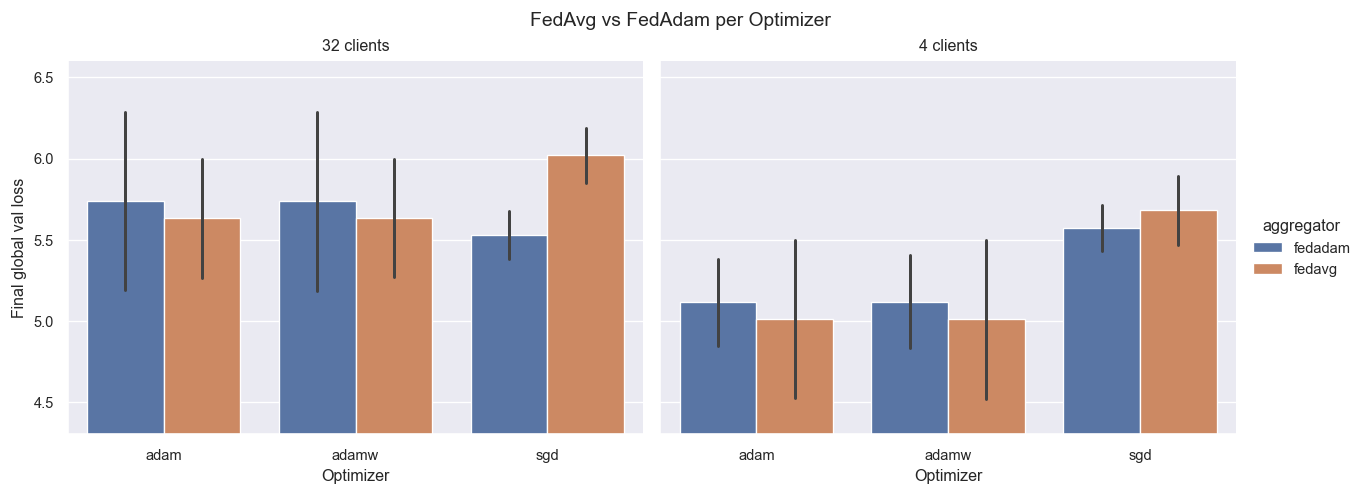

In [21]:
g = sns.catplot(data=df, x="optimizer", y="final_global_val", hue="aggregator",
                col="clients", kind="bar", errorbar="sd", height=4, aspect=1.3)
g.set_axis_labels("Optimizer", "Final global val loss")
g.set_titles("{col_name}"); g.figure.suptitle("FedAvg vs FedAdam per Optimizer", y=1.02)
for ax in g.axes.flat: ax.set_ylim(bottom=4.3)
g.savefig(FIGS_DIR / "04_aggregator.png", bbox_inches="tight")

## 7. Global val loss learning curves

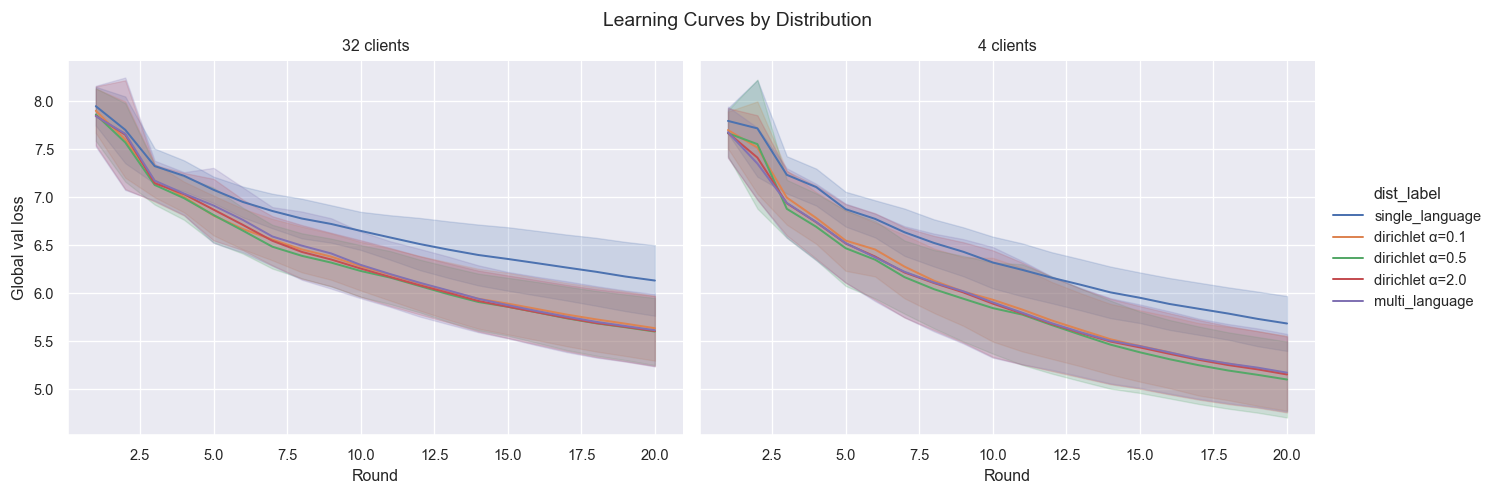

In [22]:
# By data distribution
g = sns.relplot(data=df_curves, x="round", y="global_val_loss",
                hue="dist_label", col="clients",
                kind="line", errorbar="sd", height=4, aspect=1.4,
                hue_order=DIST_ORDER)
g.set_axis_labels("Round", "Global val loss")
g.set_titles("{col_name}"); g.figure.suptitle("Learning Curves by Distribution", y=1.02)
g.savefig(FIGS_DIR / "05a_curves_dist.png", bbox_inches="tight")

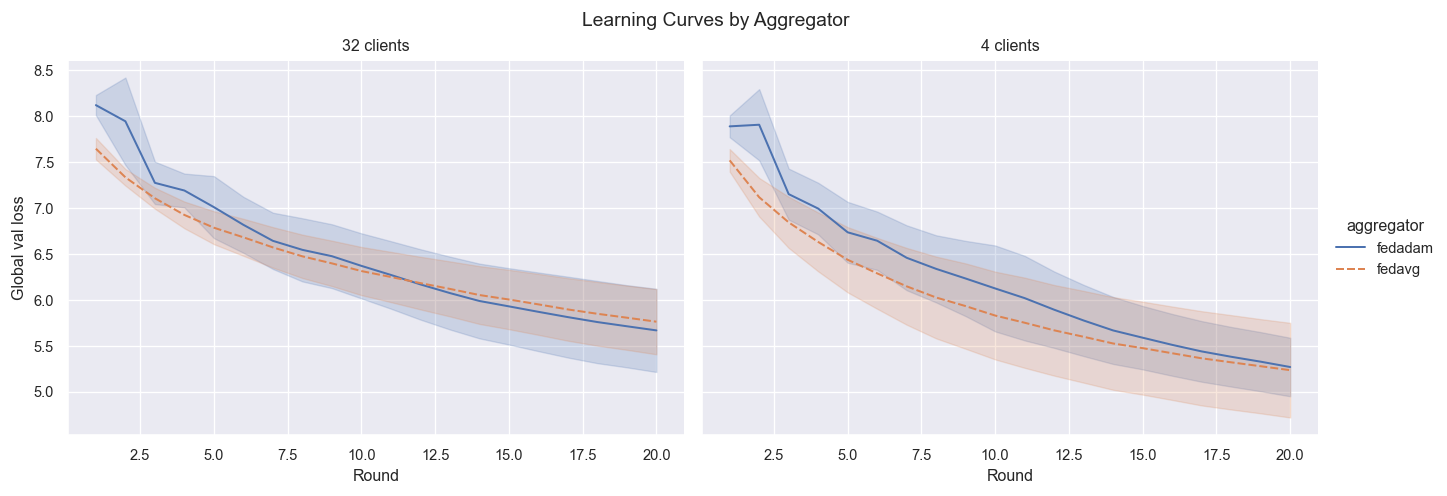

In [23]:
# By aggregator
g = sns.relplot(data=df_curves, x="round", y="global_val_loss",
                hue="aggregator", col="clients", style="aggregator",
                kind="line", errorbar="sd", height=4, aspect=1.4)
g.set_axis_labels("Round", "Global val loss")
g.set_titles("{col_name}"); g.figure.suptitle("Learning Curves by Aggregator", y=1.02)
g.savefig(FIGS_DIR / "05b_curves_agg.png", bbox_inches="tight")

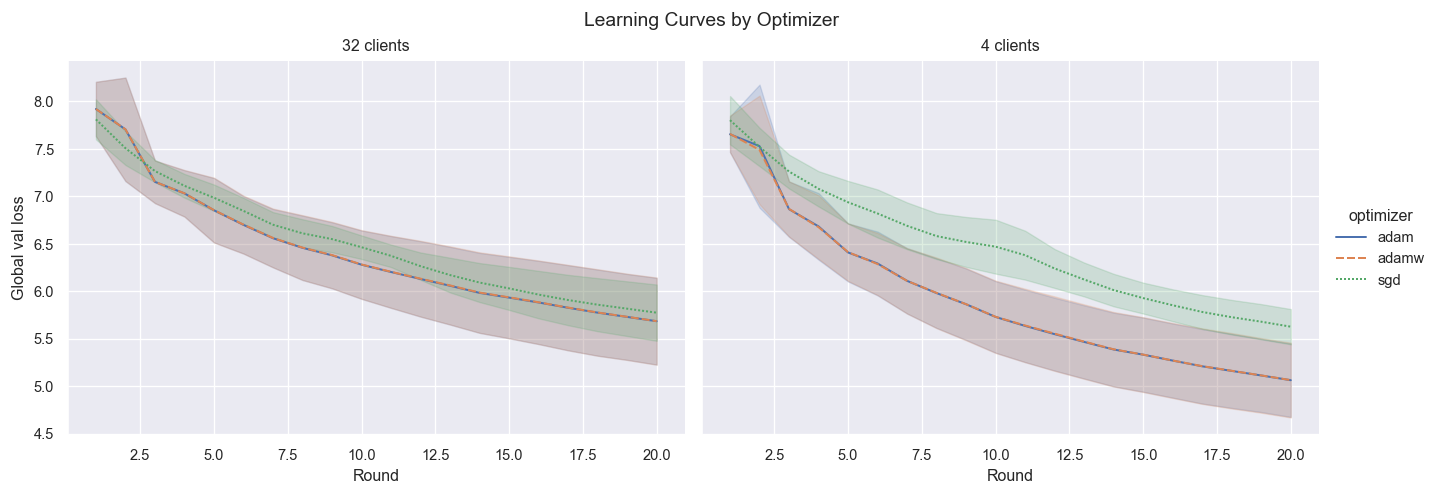

In [24]:
# By optimizer — useful to see if SGD converges differently
g = sns.relplot(data=df_curves, x="round", y="global_val_loss",
                hue="optimizer", col="clients", style="optimizer",
                kind="line", errorbar="sd", height=4, aspect=1.4)
g.set_axis_labels("Round", "Global val loss")
g.set_titles("{col_name}"); g.figure.suptitle("Learning Curves by Optimizer", y=1.02)
g.savefig(FIGS_DIR / "05c_curves_opt.png", bbox_inches="tight")

## 8. Dirichlet α heterogeneity

Lower α = more skewed client distributions.

with adam(w) only


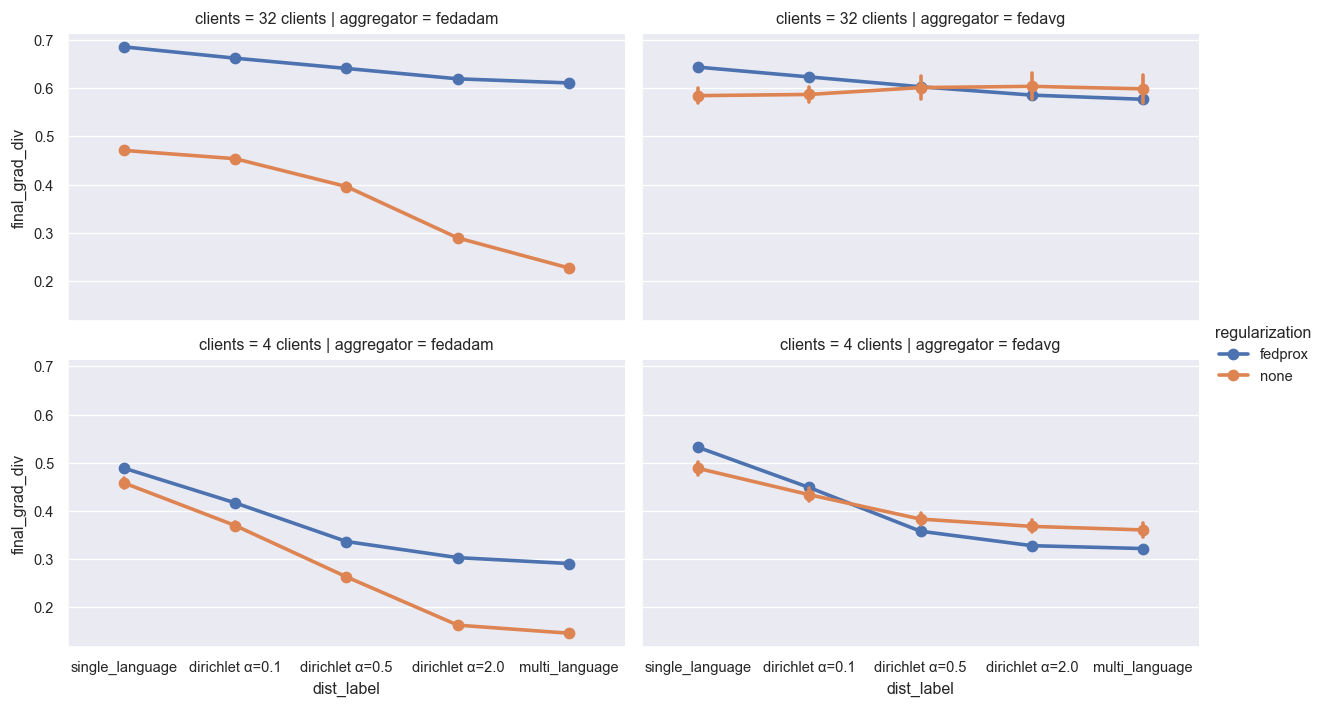

In [25]:
g = sns.catplot(data=df_opt[df_opt["optimizer"]=='adam(w)'], x="dist_label", y="final_grad_div", order=DIST_ORDER, row='clients', hue="regularization",
                kind="point", height=3, aspect=1.7, col="aggregator")
print("with adam(w) only")

with sgd only


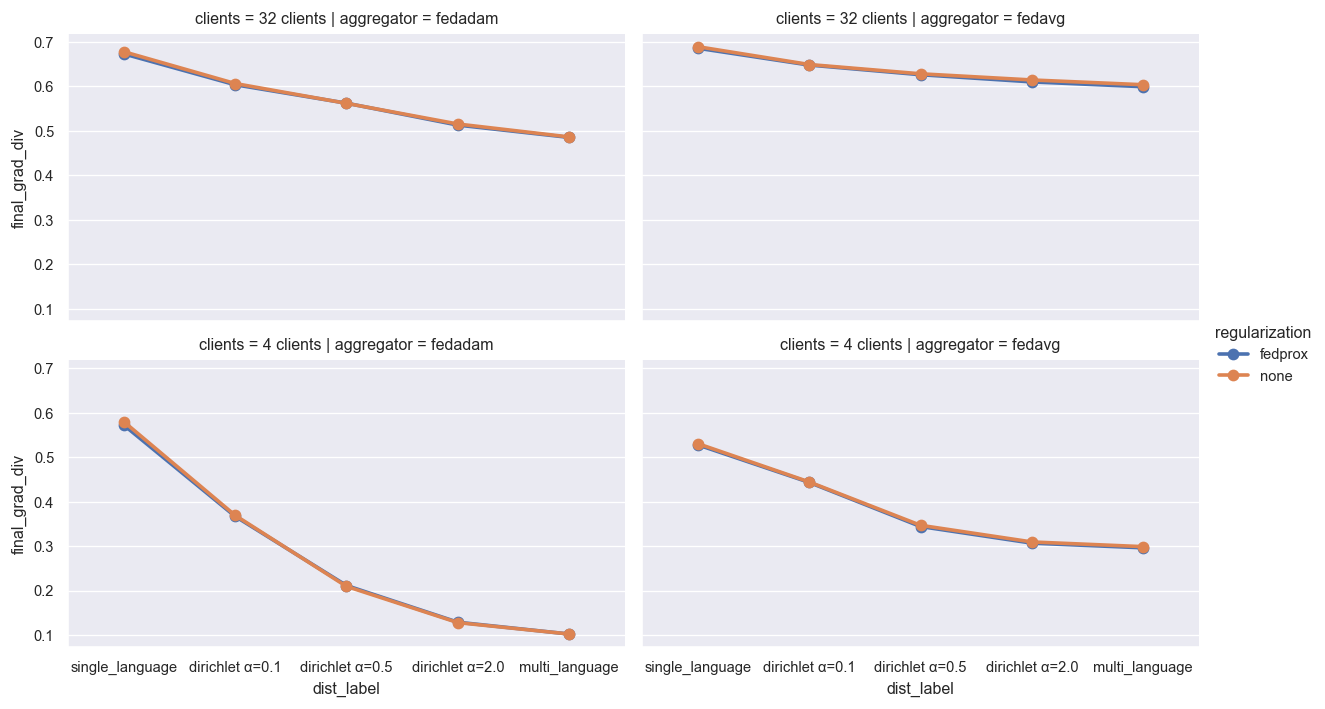

In [26]:
g = sns.catplot(data=df_opt[df_opt["optimizer"]=='sgd'], x="dist_label", y="final_grad_div", order=DIST_ORDER, row='clients', hue="regularization",
                kind="point", height=3, aspect=1.7, col="aggregator")
print("with sgd only")

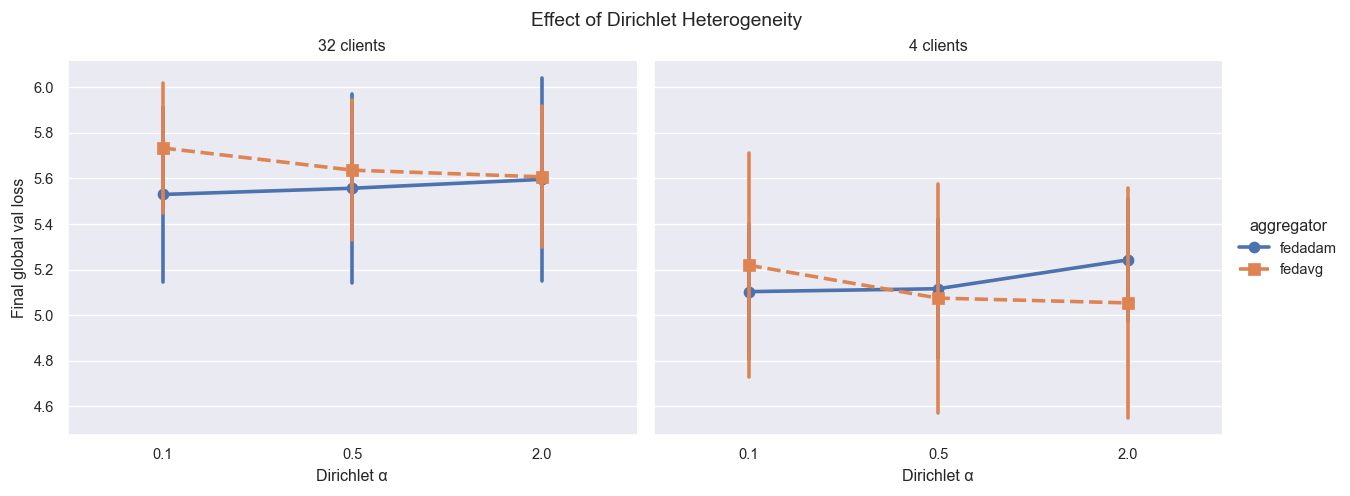

In [27]:
df_dir = df[df["distribution"] == "dirichlet"].copy()
df_dir["alpha_str"] = df_dir["dirichlet_alpha"].astype(str)   # categorical x-axis

g = sns.catplot(data=df_dir, x="dirichlet_alpha", y="final_global_val",
                hue="aggregator", col="clients",
                kind="point", errorbar="sd", height=4, aspect=1.3,
                markers=["o","s"], linestyles=["-","--"])
g.set_axis_labels("Dirichlet α", "Final global val loss")
g.set_titles("{col_name}"); g.figure.suptitle("Effect of Dirichlet Heterogeneity", y=1.02)
g.savefig(FIGS_DIR / "06_dirichlet.png", bbox_inches="tight")

## 9. FL vs centralized baseline

Points **below the diagonal** mean FL ≤ baseline (FL is competitive).

num_clients
4     0
32    0
Name: experiments where FL ≤ baseline, dtype: int64


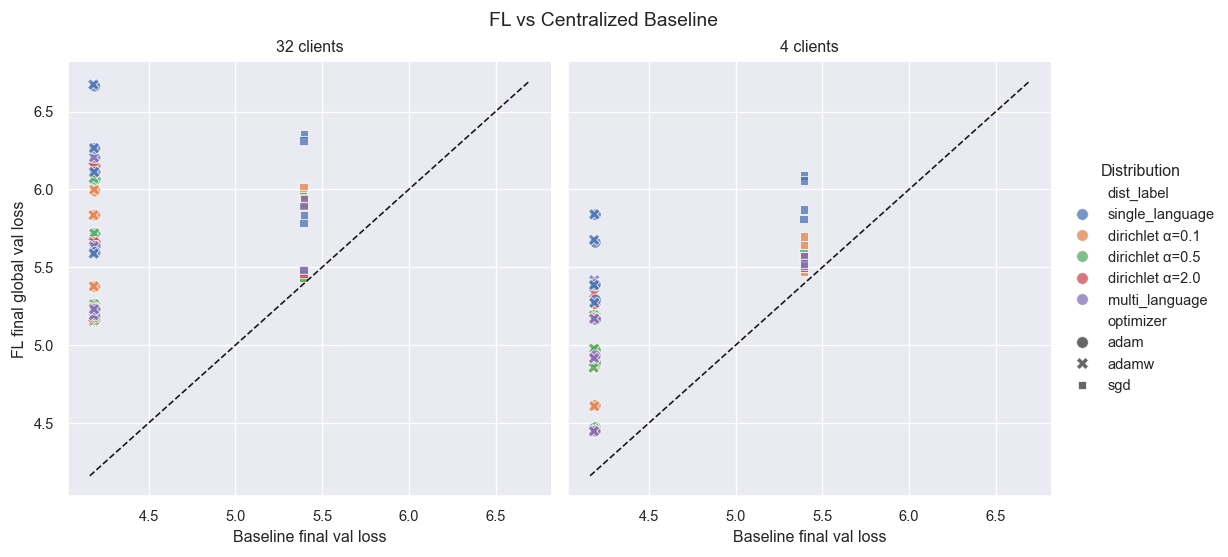

In [28]:
sub = df.dropna(subset=["baseline_final_val","final_global_val"])

g = sns.FacetGrid(sub, col="clients", height=4.5, aspect=1)
g.map_dataframe(sns.scatterplot, x="baseline_final_val", y="final_global_val",
                hue="dist_label", style="optimizer", alpha=0.75, s=50,
                hue_order=DIST_ORDER)

# diagonal
for ax in g.axes.flat:
    lo = sub[["baseline_final_val","final_global_val"]].min().min() - 0.02
    hi = sub[["baseline_final_val","final_global_val"]].max().max() + 0.02
    ax.plot([lo,hi],[lo,hi],"k--",lw=1,label="parity")

g.add_legend(title="Distribution")
g.set_axis_labels("Baseline final val loss","FL final global val loss")
g.set_titles("{col_name}")
g.figure.suptitle("FL vs Centralized Baseline", y=1.02)
g.savefig(FIGS_DIR / "07_fl_vs_baseline.png", bbox_inches="tight")

# How many experiments beat baseline?
print(df.groupby("num_clients").apply(lambda x:(x["fl_vs_baseline"]<0).sum())
        .rename("experiments where FL ≤ baseline"))

## 10. Heatmap & best configs

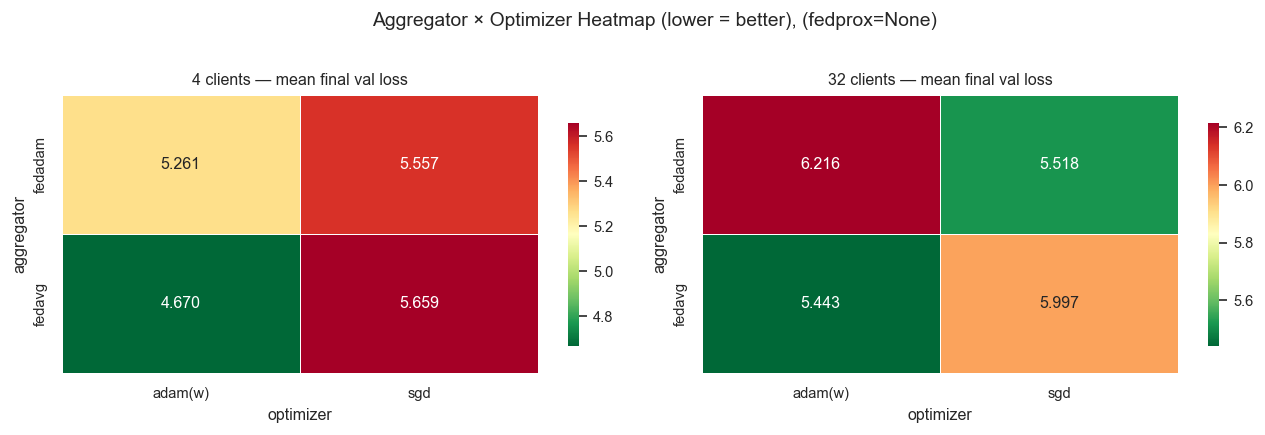

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, nc in zip(axes, [4, 32]):
    pivot = (df_opt[(df_opt["num_clients"]==nc) & (df_opt["regularization"]=='none')]
               .pivot_table("final_global_val","aggregator","optimizer",aggfunc="mean"))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn_r",
                linewidths=0.5, ax=ax, cbar_kws={"shrink":0.8})
    ax.set_title(f"{nc} clients — mean final val loss")
plt.suptitle("Aggregator × Optimizer Heatmap (lower = better), (fedprox=None)", y=1.02)
plt.tight_layout()
plt.savefig(FIGS_DIR / "08_heatmap.png", bbox_inches="tight")
plt.show()

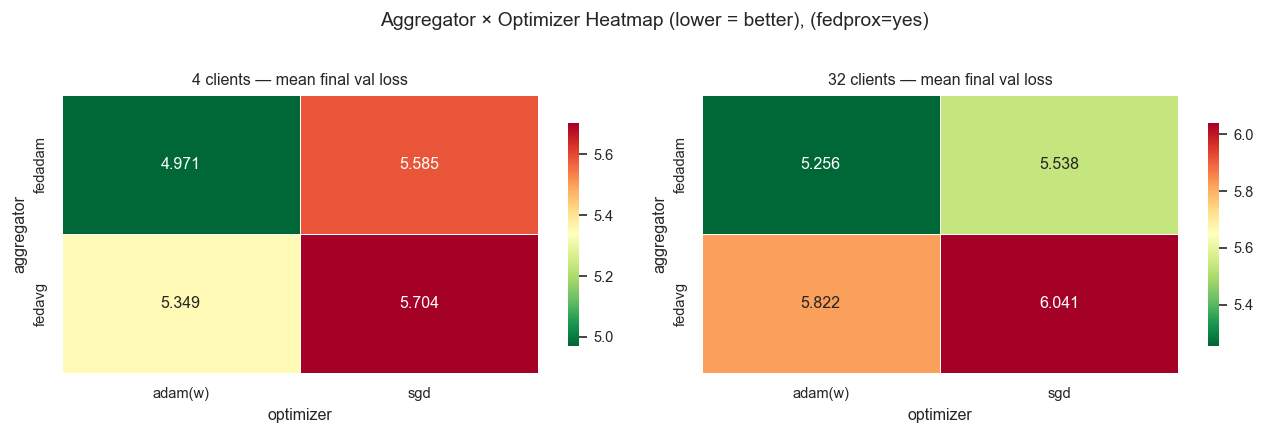

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, nc in zip(axes, [4, 32]):
    pivot = (df_opt[(df_opt["num_clients"]==nc) & (df_opt["regularization"]!='none')]
               .pivot_table("final_global_val","aggregator","optimizer",aggfunc="mean"))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn_r",
                linewidths=0.5, ax=ax, cbar_kws={"shrink":0.8})
    ax.set_title(f"{nc} clients — mean final val loss")
plt.suptitle("Aggregator × Optimizer Heatmap (lower = better), (fedprox=yes)", y=1.02)
plt.tight_layout()
plt.savefig(FIGS_DIR / "08_heatmap.png", bbox_inches="tight")
plt.show()

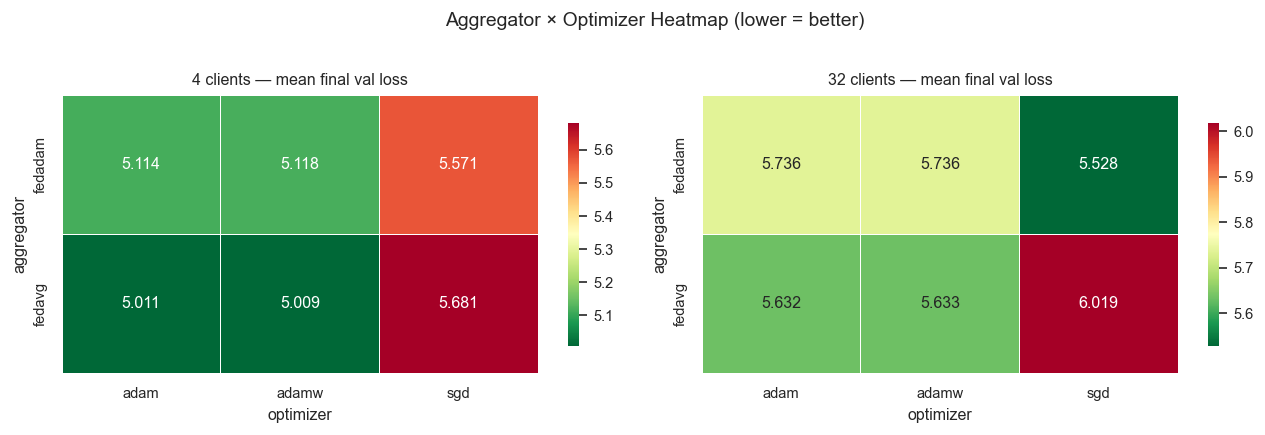

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, nc in zip(axes, [4, 32]):
    pivot = (df[df["num_clients"]==nc]
               .pivot_table("final_global_val","aggregator","optimizer",aggfunc="mean"))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn_r",
                linewidths=0.5, ax=ax, cbar_kws={"shrink":0.8})
    ax.set_title(f"{nc} clients — mean final val loss")
plt.suptitle("Aggregator × Optimizer Heatmap (lower = better)", y=1.02)
plt.tight_layout()
plt.savefig(FIGS_DIR / "08_heatmap.png", bbox_inches="tight")
plt.show()

In [32]:
# Full ranking table
cols = ["exp_id","num_clients","distribution","aggregator",
        "regularization","optimizer","final_global_val","baseline_final_val","fl_vs_baseline"]
(df.sort_values("final_global_val")[cols]
   .reset_index(drop=True)
   .head(20)
   .style.background_gradient(subset=["final_global_val"], cmap="RdYlGn_r")
         .format({"final_global_val":"{:.4f}","baseline_final_val":"{:.4f}","fl_vs_baseline":"{:+.4f}"})
)

,exp_id,num_clients,distribution,aggregator,regularization,optimizer,final_global_val,baseline_final_val,fl_vs_baseline
0,c4_dirichlet2.0_fedavg_none_adamw,4,dirichlet,fedavg,none,adamw,4.4411,4.1801,+0.2610
1,c4_dirichlet2.0_fedavg_none_adam,4,dirichlet,fedavg,none,adam,4.4463,4.1889,+0.2574
2,c4_multi_language_fedavg_none_adamw,4,multi_language,fedavg,none,adamw,4.4466,4.1814,+0.2652
3,c4_multi_language_fedavg_none_adam,4,multi_language,fedavg,none,adam,4.4469,4.1892,+0.2578
4,c4_dirichlet0.5_fedavg_none_adamw,4,dirichlet,fedavg,none,adamw,4.4609,4.1835,+0.2774
5,c4_dirichlet0.5_fedavg_none_adam,4,dirichlet,fedavg,none,adam,4.4693,4.1900,+0.2793
6,c4_dirichlet0.1_fedavg_none_adamw,4,dirichlet,fedavg,none,adamw,4.6068,4.1840,+0.4228
7,c4_dirichlet0.1_fedavg_none_adam,4,dirichlet,fedavg,none,adam,4.6117,4.1899,+0.4218
8,c4_dirichlet0.1_fedadam_fedprox_adamw,4,dirichlet,fedadam,fedprox,adamw,4.8526,4.1810,+0.6716
9,c4_dirichlet0.5_fedadam_fedprox_adamw,4,dirichlet,fedadam,fedprox,adamw,4.8552,4.1797,+0.6755


In [33]:
# Export summary CSV for further analysis
df.to_csv("results_summary.csv", index=False)
print("Saved → results_summary.csv")

Saved → results_summary.csv
